# Valorant Esports Analytics: Data Cleaning & Insights from Champions Istanbul 2022

# Import Libralie

In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

In [38]:
df = pd.read_csv('C:/Users/USER/Downloads/ValorantStatIstanbul/valorant champions istanbul.csv')

In [39]:
df.shape

(40, 14)

In [40]:
df.head(10)

,Player,Team,Nationality,Kill,Death,K/D,KAST,Prize,Role,HS %,Rounds Played,Rounds Win,Rounds Lose,Rank
0,Sacy,LOUD,Brazil,147,123,1.20,76%,"\t$60,000.00",Initiator,25.50,222,155,67,1
1,saadhak,LOUD,Argentina,150,143,1.05,76%,"\t$60,000.00",Initiator,22.50,222,155,67,1
2,pANcada,LOUD,Brazil,169,137,1.23,81%,"\t$60,000.00",Controller,36.75,222,155,67,1
3,Less,LOUD,Brazil,176,134,1.31,73%,"\t$60,000.00",Sentinel,26.50,222,155,67,1
4,aspas,LOUD,Brazil,166,158,1.05,71%,"\t$60,000.00",Duelist,26.25,222,155,67,1
5,yay,OPTC,United States,334,236,1.42,71%,"\t$30,000.00",Duelist,28.60,365,181,184,2
6,Marved,OPTC,Canada,240,252,0.95,73%,"\t$30,000.00",Controller,30.80,365,181,184,2
7,Victor,OPTC,United States,247,254,0.97,69%,"\t$30,000.00",Duelist,25.40,365,181,184,2
8,crashies,OPTC,United States,238,246,0.97,72%,"\t$30,000.00",Initiator,26.60,365,181,184,2
9,FNS,OPTC,Canada,188,247,0.76,67%,"\t$30,000.00",Sentinel,20.40,365,181,184,2


In [41]:
df.describe()

,Kill,Death,K/D,HS %,Rounds Played,Rounds Win,Rounds Lose
count,40.00000,40.000000,40.000000,40.000000,40.00000,40.000000,40.000000
mean,139.90000,139.375000,1.002500,27.223000,202.25000,103.250000,99.000000
std,68.09827,63.050524,0.217028,5.515632,94.68673,51.542241,50.102459
min,39.00000,54.000000,0.590000,15.000000,81.00000,35.000000,39.000000
25%,84.25000,82.250000,0.855000,23.750000,136.00000,63.750000,63.500000
50%,141.00000,129.500000,0.960000,26.800000,198.50000,98.500000,84.500000
75%,180.50000,175.250000,1.110000,30.447500,244.75000,147.500000,126.000000
max,334.00000,254.000000,1.520000,38.800000,365.00000,181.000000,184.000000


# Check Duplicated Value

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Player         40 non-null     object 
 1   Team           40 non-null     object 
 2   Nationality    40 non-null     object 
 3   Kill           40 non-null     int64  
 4   Death          40 non-null     int64  
 5   K/D            40 non-null     float64
 6   KAST           40 non-null     object 
 7   Prize          40 non-null     object 
 8   Role           40 non-null     object 
 9   HS %           40 non-null     float64
 10  Rounds Played  40 non-null     int64  
 11  Rounds Win     40 non-null     int64  
 12  Rounds Lose    40 non-null     int64  
 13  Rank           40 non-null     object 
dtypes: float64(2), int64(5), object(7)
memory usage: 4.5+ KB


In [43]:
df_check_dup = df.duplicated().sum()
print('Duplicated Data = ',df_check_dup)

Duplicated Data =  0


# Check Missing Value

In [44]:
df_check_null = df.isnull().sum()
df_check_null

Player           0
Team             0
Nationality      0
Kill             0
Death            0
K/D              0
KAST             0
Prize            0
Role             0
HS %             0
Rounds Played    0
Rounds Win       0
Rounds Lose      0
Rank             0
dtype: int64

# Check Inconsistent Datatype

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Player         40 non-null     object 
 1   Team           40 non-null     object 
 2   Nationality    40 non-null     object 
 3   Kill           40 non-null     int64  
 4   Death          40 non-null     int64  
 5   K/D            40 non-null     float64
 6   KAST           40 non-null     object 
 7   Prize          40 non-null     object 
 8   Role           40 non-null     object 
 9   HS %           40 non-null     float64
 10  Rounds Played  40 non-null     int64  
 11  Rounds Win     40 non-null     int64  
 12  Rounds Lose    40 non-null     int64  
 13  Rank           40 non-null     object 
dtypes: float64(2), int64(5), object(7)
memory usage: 4.5+ KB


In [46]:
#Check unique value
for col in df.select_dtypes('object'):
    print(df[col].unique())

['Sacy' 'saadhak' 'pANcada' 'Less' 'aspas' 'yay' 'Marved' 'Victor'
 'crashies' 'FNS' 'MaKo' 'BuZz' 'Zest' 'stax' 'Rb' 'Zyppan' 'ardiis'
 'SUYGETSU' 'Shao' 'ANGE1' 'AYRIN' 'BcJ' 'Cryocells' 'dephh' 'zekken'
 'Derke' 'Enzo' 'Alfajer' 'Boaster' 'Mistic' 'Nivera' 'Jamppi' 'Scream'
 'dimasick' 'soulcas' 'kiNgg' 'adverso' 'Melser' 'Tacolilla' 'Shyy']
['LOUD' 'OPTC' 'DRX' 'FPX' 'XSET' 'FNC' 'TL' 'LEV']
['Brazil' 'Argentina' 'United States' 'Canada' 'South Corea' 'Sweeden'
 'Latvia' 'International' 'Ukraine' 'United Kingdom' 'Finland' 'France'
 'Turkey' 'Belgium' 'Kazakhstan' 'Chile']
['76%' '81%' '73%' '71%' '69%' '72%' '67%' '77%' '66%' '70%' '79%' '60%'
 '68%' '63%' '57%' '64%' '75%']
['\t$60,000.00' '\t$30,000.00' '\t$22,000.00' '\t$16,000.00'
 '\t$12,000.00' '\t$8,000.00']
['Initiator' 'Controller' 'Sentinel' 'Duelist' 'Flex']
['1' '2' '3' '4' '5,6' '7,8']


In [47]:
df['Prize'].head(10)

0    \t$60,000.00
1    \t$60,000.00
2    \t$60,000.00
3    \t$60,000.00
4    \t$60,000.00
5    \t$30,000.00
6    \t$30,000.00
7    \t$30,000.00
8    \t$30,000.00
9    \t$30,000.00
Name: Prize, dtype: object

In [48]:
df['Prize'] = df['Prize'].str.replace('\t','')

In [49]:
df_dead_dup = df[df.duplicated(subset='Kill',keep=False)].sort_values(by='Kill',ascending=False)
df_dead_dup 

,Player,Team,Nationality,Kill,Death,K/D,KAST,Prize,Role,HS %,Rounds Played,Rounds Win,Rounds Lose,Rank
13,stax,DRX,South Corea,192,207,0.93,69%,"$22,000.00",Initiator,38.80,313,145,168,3
14,Rb,DRX,South Corea,192,228,0.84,69%,"$22,000.00",Flex,25.80,313,145,168,3
0,Sacy,LOUD,Brazil,147,123,1.20,76%,"$60,000.00",Initiator,25.50,222,155,67,1
25,Derke,FNC,Finland,147,99,1.48,69%,"$12,000.00",Flex,33.33,152,79,73,"5,6"
33,dimasick,TL,Kazakhstan,54,74,0.73,67%,"$8,000.00",Controller,38.50,81,42,39,"7,8"
37,Melser,LEV,Chile,54,57,0.95,70%,"$8,000.00",Flex,27.50,88,35,53,"7,8"


# Stax กับ Rb คือ 2 คนที่มี Killเท่ากันเยอะสุดใน tour

In [50]:
df[['Player','Kill']].head(10).sort_values(by='Kill',ascending=False)

,Player,Kill
5,yay,334
7,Victor,247
6,Marved,240
8,crashies,238
9,FNS,188
3,Less,176
2,pANcada,169
4,aspas,166
1,saadhak,150
0,Sacy,147


# Yay Kill เยอะสุดในทัวร์

# EDA

In [51]:
df_hs = df[['Player','HS %']]
df_hs = df_hs.sort_values(by='HS %',ascending=False)
df_hs

,Player,HS %
13,stax,38.80
33,dimasick,38.50
2,pANcada,36.75
12,Zest,36.00
30,Nivera,33.50
34,soulcas,33.50
25,Derke,33.33
17,SUYGETSU,33.00
10,MaKo,31.20
6,Marved,30.80


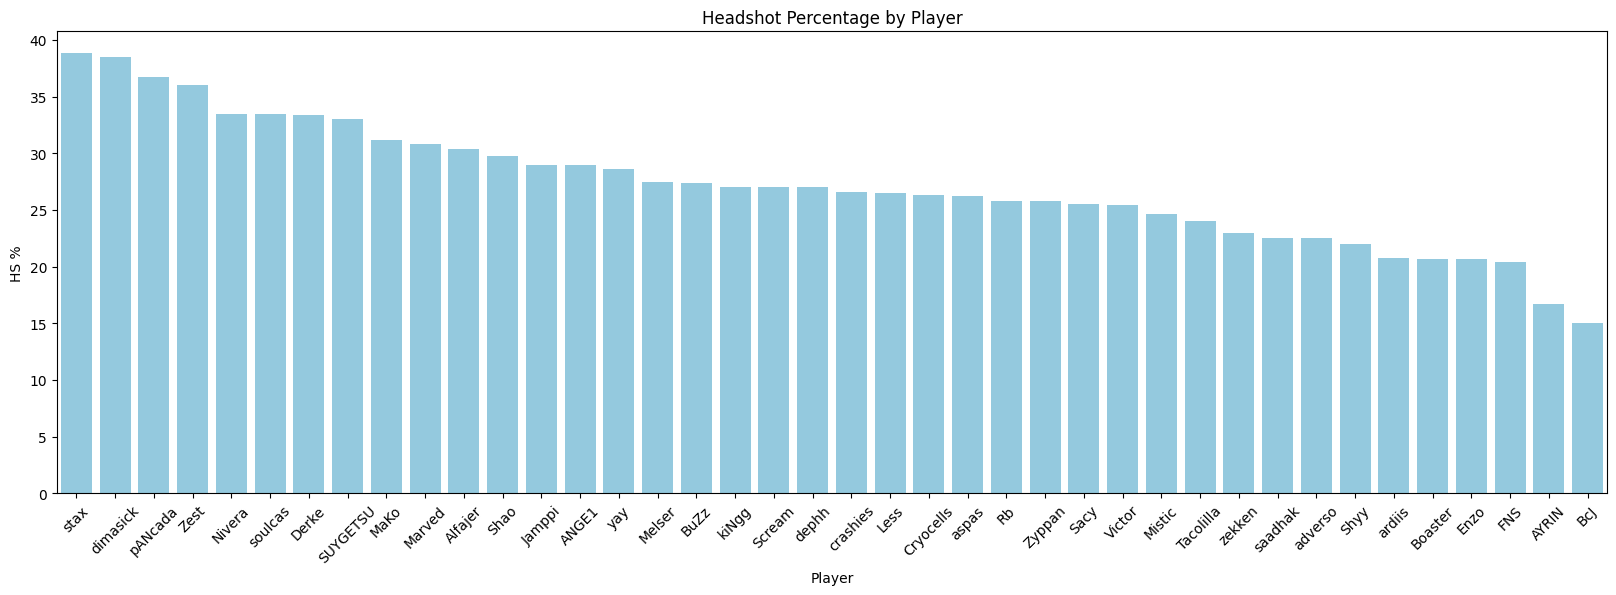

In [52]:
plt.figure(figsize=(20,6))
sns.barplot(data=df_hs,x='Player',y='HS %',color='skyblue')
plt.xticks(rotation=45)
plt.title('Headshot Percentage by Player')
plt.show()

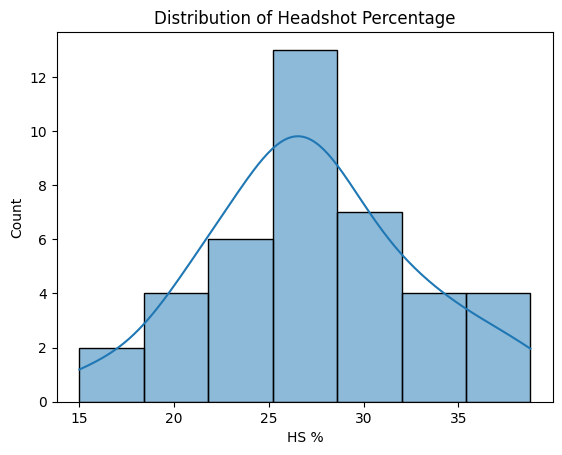

In [53]:
sns.histplot(df_hs['HS %'], kde=True)
plt.title('Distribution of Headshot Percentage')
plt.show()


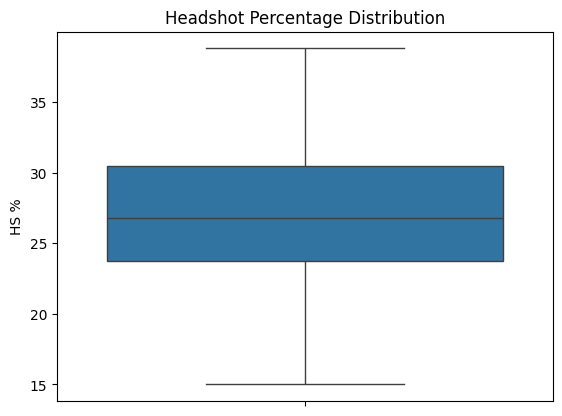

In [54]:
sns.boxplot(y=df_hs['HS %'])
plt.title('Headshot Percentage Distribution')
plt.show()

In [55]:
df_nationality = df['Nationality'].value_counts()
df_nationality

Nationality
United States     6
South Corea       5
Chile             5
Brazil            4
United Kingdom    4
Canada            3
International     2
Belgium           2
Finland           2
Latvia            1
Argentina         1
Sweeden           1
France            1
Ukraine           1
Turkey            1
Kazakhstan        1
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

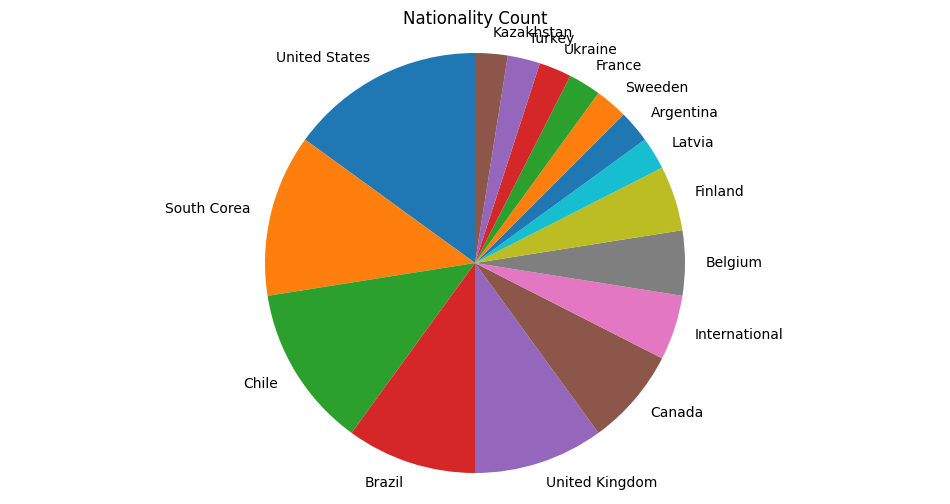

In [56]:
plt.figure(figsize=(12,6))
plt.pie(df_nationality.values,labels=df_nationality.index, startangle=90)
plt.title('Nationality Count')
plt.axis('equal')
plt.show

In [57]:
#Most Kill by Team
df_mostkill_byteam = df.groupby('Team')['Kill'].sum().sort_values(ascending=False)
df_mostkill_byteam

Team
OPTC    1247
DRX     1048
LOUD     808
FPX      731
XSET     638
FNC      532
TL       307
LEV      285
Name: Kill, dtype: int64

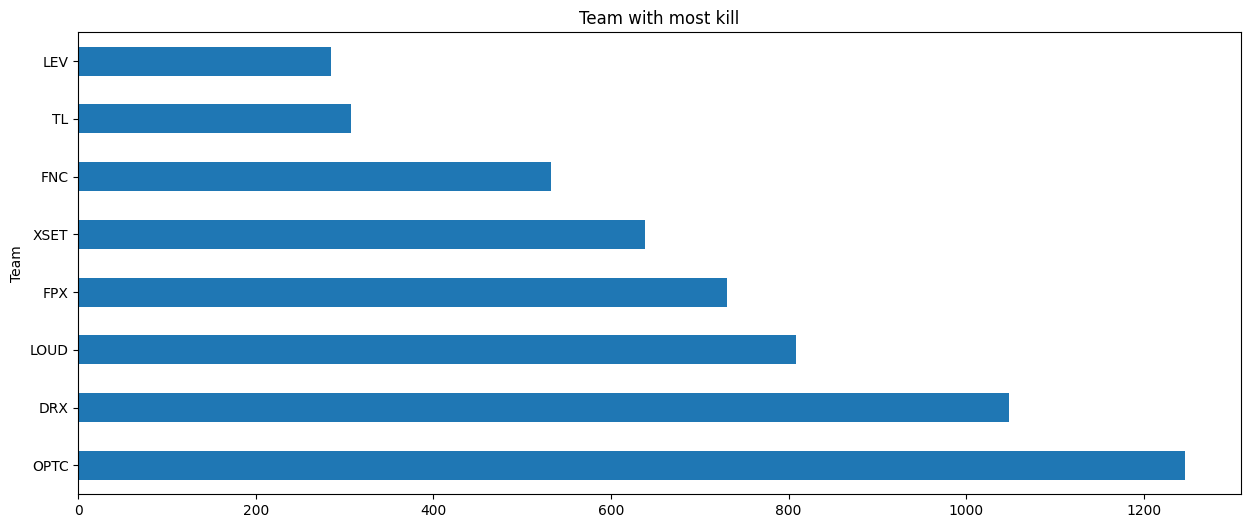

In [58]:
plt.figure(figsize=(15,6))
df_mostkill_byteam.plot(kind='barh')
plt.title("Team with most kill")
plt.show()

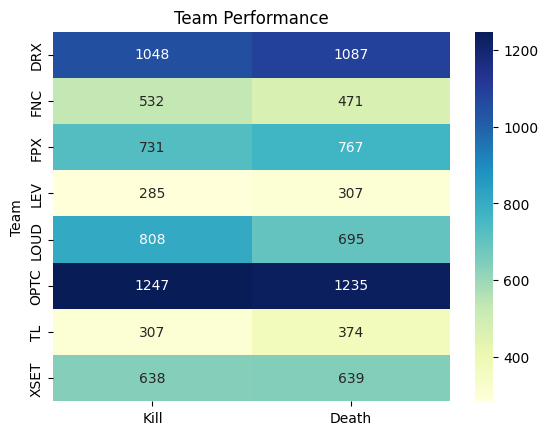

In [59]:
team_data = df.groupby('Team')[['Kill','Death']].sum()
sns.heatmap(data=team_data,annot=True,fmt='d', cmap='YlGnBu') #annot = แสดงค่าตัวเลขบน heatmap fmt = format ตัวเลข
plt.title('Team Performance')
plt.show()

# Machine Learning Predict Ranking

In [60]:
df['Winrate'] = df['Rounds Win'] /df['Rounds Played']
df.head(10)

,Player,Team,Nationality,Kill,Death,K/D,KAST,Prize,Role,HS %,Rounds Played,Rounds Win,Rounds Lose,Rank,Winrate
0,Sacy,LOUD,Brazil,147,123,1.20,76%,"$60,000.00",Initiator,25.50,222,155,67,1,0.698198
1,saadhak,LOUD,Argentina,150,143,1.05,76%,"$60,000.00",Initiator,22.50,222,155,67,1,0.698198
2,pANcada,LOUD,Brazil,169,137,1.23,81%,"$60,000.00",Controller,36.75,222,155,67,1,0.698198
3,Less,LOUD,Brazil,176,134,1.31,73%,"$60,000.00",Sentinel,26.50,222,155,67,1,0.698198
4,aspas,LOUD,Brazil,166,158,1.05,71%,"$60,000.00",Duelist,26.25,222,155,67,1,0.698198
5,yay,OPTC,United States,334,236,1.42,71%,"$30,000.00",Duelist,28.60,365,181,184,2,0.495890
6,Marved,OPTC,Canada,240,252,0.95,73%,"$30,000.00",Controller,30.80,365,181,184,2,0.495890
7,Victor,OPTC,United States,247,254,0.97,69%,"$30,000.00",Duelist,25.40,365,181,184,2,0.495890
8,crashies,OPTC,United States,238,246,0.97,72%,"$30,000.00",Initiator,26.60,365,181,184,2,0.495890
9,FNS,OPTC,Canada,188,247,0.76,67%,"$30,000.00",Sentinel,20.40,365,181,184,2,0.495890


In [61]:
categorical_cols = ['Player','Team','Nationality','Role']
for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col]) #ML ต้องใช้ข้อมูลเป็นตัวเลขเราจึงแปลงคอลัมน์ที่เป็นคำ (เช่น Player, Team, Role) ให้เป็นตัวเลข เช่น "Duelist" → 0, "Sentinel" → 1 เป็นต้น


In [62]:
# แบ่งข้อมูล x(input) และ y(target)
X = df.drop(['Rank','Prize','KAST'], axis = 1) # axis 0 = row,axis 1 = column
y = df['Rank']

In [63]:
#Scaling ปรับขนาดข้อมูล
#ทำให้ตัวเลขทุกคอลัมน์อยู่ในสเกลใกล้เคียงกัน เช่นจาก [0, 100] → [-1, 1]
#ช่วยให้โมเดลทำงานได้ดีขึ้น (โดยเฉพาะกับข้อมูลที่มีค่าสูง ๆ ต่ำ ๆ ผสมกัน)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled,y,test_size=0.2,random_state=42) #Test 20% , Train 80% , random_state = ช่วยให้ผลลัพธ์เหมือนเดิมทุกครั้ง

In [65]:
model = RandomForestClassifier()
model.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [66]:
#ให้โมเดลลองทำนาย rank จากข้อมูลที่มันไม่เคยเห็น (X_test)
#→ ผลลัพธ์อยู่ในตัวแปร y_pred
y_pred = model.predict(X_test)

In [67]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           1       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         3
         5,6       1.00      1.00      1.00         2
         7,8       1.00      1.00      1.00         1

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



<Axes: >

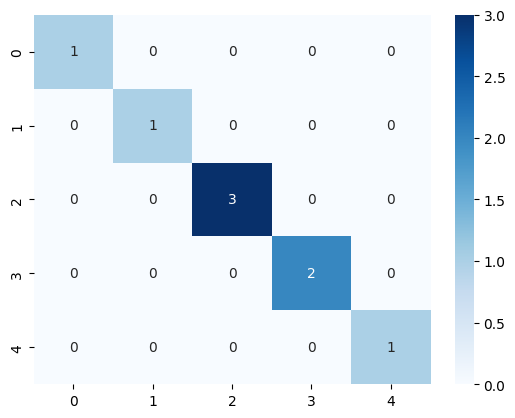

In [68]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap="Blues")


# ทายถูกหมด อาจเพราะ Dataน้อยเกินไป

In [69]:
#นับจำนวนทีม
df["Team"].nunique() #.nunique() คือการนับจำนวนค่าที่ไม่ซ้ำกันในคอลัมน์นั้น

8